In [6]:
pip install yfinance

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [8]:
# Download Apple stock data
data = yf.download("AAPL", start="2022-01-01", end="2024-01-01")

print(data.head())

Failed to get ticker 'AAPL' reason: Failed to perform, curl: (56) Connection closed abruptly. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.
[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open     Volume
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL
Date                                                                 
2022-01-03  178.103622  178.954960  173.895923  174.013342  104487900
2022-01-04  175.843246  179.013714  175.275693  178.710370   99310400
2022-01-05  171.165833  176.303156  170.891843  175.755177   94537600
2022-01-06  168.308502  171.537680  167.956228  168.993476   96904000
2022-01-07  168.474838  170.402559  167.359306  169.179387   86709100


In [9]:
X = data[['Open', 'High', 'Low', 'Volume']]
y = data['Close']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

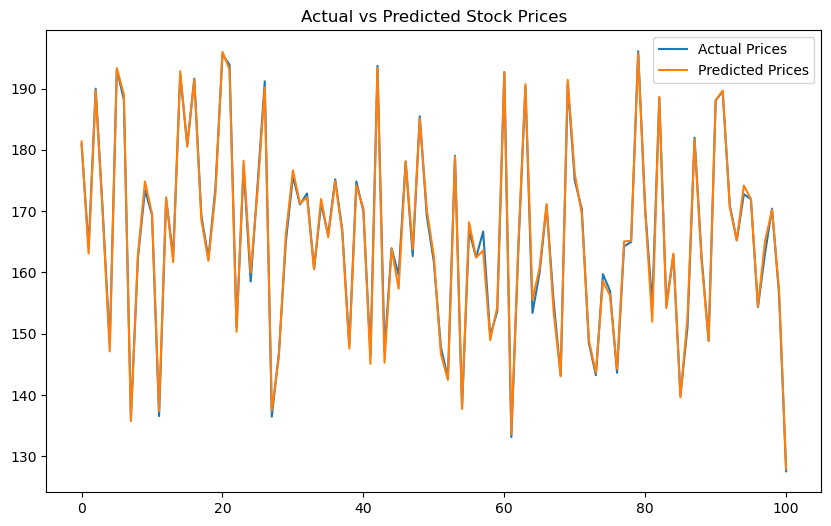

In [11]:
plt.figure(figsize=(10,6))

plt.plot(y_test.values, label="Actual Prices")
plt.plot(predictions, label="Predicted Prices")

plt.legend()
plt.title("Actual vs Predicted Stock Prices")
plt.show()